# Notes
- Position limits:
    - Emeralds: 80
    - Tomatoes: 80
- Tomatoes fluctuate more 
- Elemeralds are pretty constant
- Ideas to test
    - Suitability of time series models
    - making signals out of aggressor orders
        - size of spread crossed
        - qty


- Theres less volume for best quotes in the test data??

In [7]:
import numpy as np
import pandas as pd
import sklearn as sk
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels as sm


def fa(n,m, a, b):
    f,a = plt.subplots(n,m, figsize = (a,b))
    return f,a

In [9]:
# load data 
# day -2 is train, day -1 is test
products = ['TOMATOES', 'EMERALDS']


prices_train = pd.read_csv(r'prices_round_0_day_-2.csv', delimiter = ';')
prices_test = pd.read_csv(r'prices_round_0_day_-1.csv', delimiter = ';')

trades_train = pd.read_csv(r'trades_round_0_day_-2.csv', delimiter = ';')
trades_test = pd.read_csv(r'trades_round_0_day_-1.csv', delimiter = ';')

# filter by product
prices_train = {'TOMATOES': prices_train[prices_train['product'] == 'TOMATOES'], 'EMERALDS': prices_train[prices_train['product'] == 'EMERALDS']}
trades_train = {'TOMATOES': trades_train[trades_train['symbol'] == 'TOMATOES'], 'EMERALDS': trades_train[trades_train['symbol'] == 'EMERALDS']}

#-----
for prod in products:
    # tidying data
    prices_train[prod] = prices_train[prod].drop(columns = ['product' , 'day', 'profit_and_loss'])
    trades_train[prod] = trades_train[prod].drop(columns = ['symbol' ])
    prices_train[prod].index = np.arange(len(prices_train[prod]))
    trades_train[prod]['timestamp'] = (trades_train[prod]['timestamp']/100).astype(int)
    prices_train[prod]['timestamp'] = (prices_train[prod]['timestamp']/100).astype(int)

    # adding spread column to prices data
    prices_train[prod]['spread'] = prices_train[prod]['ask_price_1'] - prices_train[prod]['bid_price_1']

    # filling data into trades df
    # adding market info to trades data
    trades_train[prod] = pd.merge(prices_train[prod], trades_train[prod], on = 'timestamp', how = 'inner')
    # adding aggressor's direction of trade 
        # CHECK FOR NBP (Not best price) trades
    trades_train[prod]['direction'] = np.where(trades_train[prod]['price'] == trades_train[prod]['ask_price_1'], 'buy', 
                                               np.where(trades_train[prod]['price'] == trades_train[prod]['bid_price_1'], 'sell', 'NBP'))
    



# ease of access
tomatoes_prices = prices_train['TOMATOES']
emeralds_prices = prices_train['EMERALDS']
tomatoes_trades = trades_train['TOMATOES']
emeralds_trades = trades_train['EMERALDS']

<Axes: >

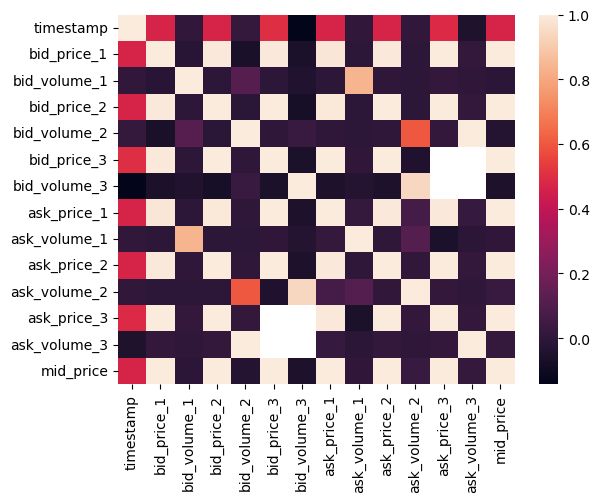

In [4]:
# correlation plot and matrix

sns.heatmap(prices_train['TOMATOES'].corr(), annot = False)

## Investigating trades that occurred

### Tomatoes

In [92]:
# # adding price info to trades data
# tomatoes_trades = pd.merge(tomatoes_prices, tomatoes_trades, on = 'timestamp', how = 'inner')

# # adding aggressor's direction of trade 
# tomatoes_trades['direction'] = np.where(tomatoes_trades['price'] == tomatoes_trades['ask_price_1'], 'buy', 
#                                         np.where(tomatoes_trades['price'] == tomatoes_trades['bid_price_1'], 'sell', 'NBP'))

In [84]:
tomatoes_trades['direction'].value_counts()

direction
sell    208
buy     189
Name: count, dtype: int64

In [86]:
tomatoes_trades

,timestamp,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,buyer,seller,currency,price,quantity,direction
0,9,4994,5,4993,24,NaN,NaN,5008,5,5009,24,NaN,NaN,5001.0,NaN,NaN,XIRECS,5008.0,2,buy
1,17,4993,5,4992,18,NaN,NaN,5006,5,5008,18,NaN,NaN,4999.5,NaN,NaN,XIRECS,5006.0,3,buy
2,41,4989,5,4987,17,NaN,NaN,5002,5,5003,17,NaN,NaN,4995.5,NaN,NaN,XIRECS,5002.0,3,buy
3,67,4988,8,4987,20,NaN,NaN,5001,8,5003,20,NaN,NaN,4994.5,NaN,NaN,XIRECS,4988.0,5,sell
4,71,4987,6,4986,17,NaN,NaN,5000,6,5002,17,NaN,NaN,4993.5,NaN,NaN,XIRECS,5000.0,3,buy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392,9861,5002,8,5001,23,NaN,NaN,5016,8,5017,23,NaN,NaN,5009.0,NaN,NaN,XIRECS,5002.0,5,sell
393,9886,5004,7,5003,22,NaN,NaN,5018,7,5019,22,NaN,NaN,5011.0,NaN,NaN,XIRECS,5004.0,5,sell
394,9893,5003,10,5002,19,NaN,NaN,5017,10,5018,19,NaN,NaN,5010.0,NaN,NaN,XIRECS,5017.0,2,buy
395,9915,5004,9,5003,15,NaN,NaN,5017,9,5019,15,NaN,NaN,5010.5,NaN,NaN,XIRECS,5017.0,2,buy


<Axes: xlabel='timestamp', ylabel='price'>

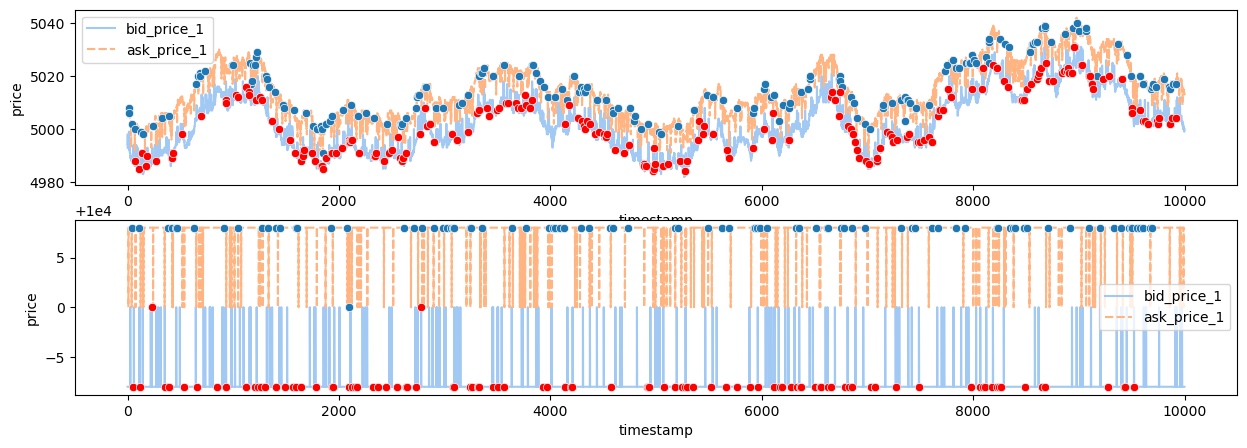

In [133]:
f,a = fa(2,1, 15,5)
sns.scatterplot(x = tomatoes_trades.timestamp, y = tomatoes_trades[tomatoes_trades['direction'] == 'buy']['price'], ax = a[0], zorder = 3)
sns.scatterplot(x = tomatoes_trades.timestamp, y = tomatoes_trades[tomatoes_trades['direction'] == 'sell']['price'], ax = a[0], zorder = 3, color = 'red')
sns.lineplot( [tomatoes_prices['bid_price_1'], tomatoes_prices['ask_price_1']], ax = a[0], palette = 'pastel')


sns.scatterplot(x = emeralds_trades.timestamp, y = emeralds_trades[emeralds_trades['direction'] == 'buy']['price'], ax = a[1], zorder = 3)
sns.scatterplot(x = emeralds_trades.timestamp, y = emeralds_trades[emeralds_trades['direction'] == 'sell']['price'], ax = a[1], zorder = 3, color = 'red')
sns.lineplot( [emeralds_prices['bid_price_1'], emeralds_prices['ask_price_1']], ax = a[1], palette = 'pastel')

In [95]:
tomatoes_prices['spread'] = tomatoes_prices['ask_price_1'] - tomatoes_prices['bid_price_1']

<Axes: ylabel='Count'>

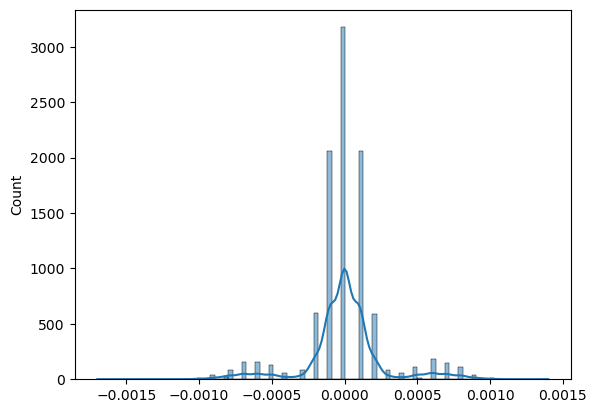

In [112]:
sns.histplot(np.diff(np.log(tomatoes_prices['mid_price']), 1), bins = 100, kde = True)

Looks pretty much like white noise

In [118]:
emeralds_trades

,timestamp,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,...,ask_price_3,ask_volume_3,mid_price,spread,buyer,seller,currency,price,quantity,direction
0,40,9992,10,9990,27,NaN,NaN,10008,10,10010,...,NaN,NaN,10000.0,16,NaN,NaN,XIRECS,10008.0,7,buy
1,52,9992,12,9990,25,NaN,NaN,10008,12,10010,...,NaN,NaN,10000.0,16,NaN,NaN,XIRECS,9992.0,5,sell
2,105,9992,10,9990,20,NaN,NaN,10008,10,10010,...,NaN,NaN,10000.0,16,NaN,NaN,XIRECS,10008.0,5,buy
3,113,9992,12,9990,21,NaN,NaN,10008,12,10010,...,NaN,NaN,10000.0,16,NaN,NaN,XIRECS,9992.0,3,sell
4,228,10000,6,9992,10,9990.0,20.0,10008,10,10010,...,NaN,NaN,10004.0,8,NaN,NaN,XIRECS,10000.0,6,sell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,9546,9992,11,9990,28,NaN,NaN,10008,11,10010,...,NaN,NaN,10000.0,16,NaN,NaN,XIRECS,10008.0,5,buy
187,9574,9992,13,9990,28,NaN,NaN,10008,13,10010,...,NaN,NaN,10000.0,16,NaN,NaN,XIRECS,10008.0,8,buy
188,9603,9992,11,9990,21,NaN,NaN,10008,11,10010,...,NaN,NaN,10000.0,16,NaN,NaN,XIRECS,10008.0,4,buy
189,9669,9992,10,9990,23,NaN,NaN,10008,10,10010,...,NaN,NaN,10000.0,16,NaN,NaN,XIRECS,10008.0,6,buy


In [ ]:
sns.lineplot()

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

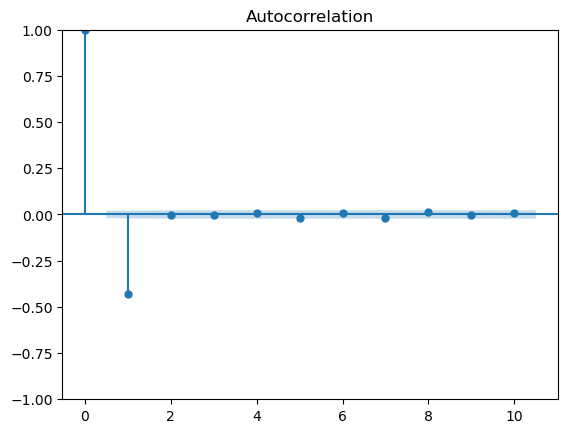

In [162]:

sm.graphics.tsa.plot_acf(np.diff(np.log(tomatoes_prices['mid_price']),1), lags=10)
plt.show()

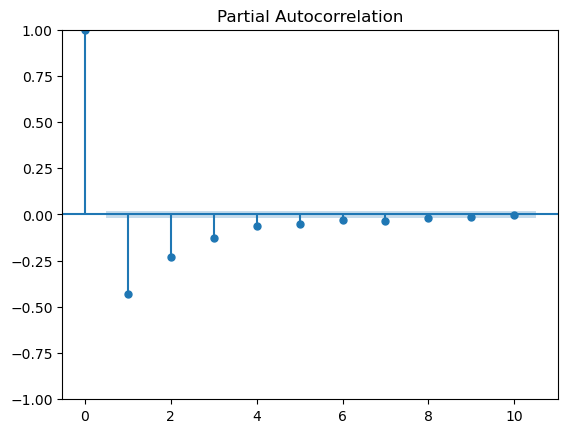

In [163]:

sm.graphics.tsa.plot_pacf(np.diff(np.log(tomatoes_prices['mid_price']),1), lags=10)
plt.show()

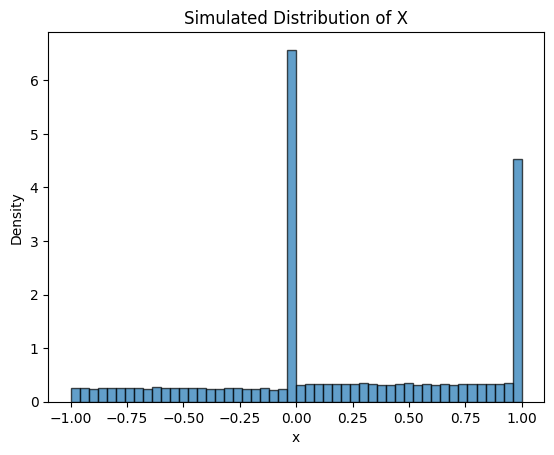

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_X(size=1000):
    # Generate uniform random variables between 0 and 1
    u = np.random.uniform(0, 1, size)
    x = np.zeros(size)
    
    # 1. Continuous part: -1 <= x < 0
    mask1 = u < 0.25
    x[mask1] = 4 * u[mask1] - 1
    
    # 2. Discrete point mass at x = 0
    mask2 = (u >= 0.25) & (u < 0.5)
    x[mask2] = 0
    
    # 3. Continuous part: 0 < x < 1
    mask3 = (u >= 0.5) & (u < 5/6)
    x[mask3] = 3 * u[mask3] - 1.5
    
    # 4. Discrete point mass at x = 1
    mask4 = u >= 5/6
    x[mask4] = 1
    
    return x

# Simulate 100,000 variables
simulated_data = simulate_X(100000)

# Optional: Plot a histogram to verify the distribution
plt.hist(simulated_data, bins=50, density=True, alpha=0.7, edgecolor='black')
plt.title('Simulated Distribution of X')
plt.xlabel('x')
plt.ylabel('Density')
plt.show()

array([1.00000000e+00, 7.51037821e-04, 1.25051925e-02, ...,
       1.00000000e+00, 9.39961455e-02, 0.00000000e+00], shape=(100000,))

In [7]:
sum(simulated_data**2)/100000

np.float64(0.36220928853175216)